# Customer Sentiment Analysis for Service Quality Improvement
## Summative Assignment - Deep Learning Course

**Student:** Mutesi Uwase Sonia
**Date:** June 2026
**Dataset:** Customer Support on Twitter (Kaggle)  

---

## Problem Statement
Inadequate customer service is a common problem in various industries in Africa such as healthcare, banks, telecommunication services, and even governments. In this project, we shall use machine learning as well as deep learning methods to analyze customer sentiments from actual customer support experiences.


---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup and Data Loading
This section mounts Google Drive, extracts the dataset, and loads it into a Pandas DataFrame for exploration.

In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (1).zip'
extract_path = '/content/customer_support'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

for f in os.listdir(extract_path):
    print(f)

twcs
sample.csv


In [9]:
import pandas as pd

df = pd.read_csv('/content/customer_support/twcs/twcs.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(2811774, 7)
   tweet_id   author_id  inbound                      created_at  \
0         1  sprintcare    False  Tue Oct 31 22:10:47 +0000 2017   
1         2      115712     True  Tue Oct 31 22:11:45 +0000 2017   
2         3      115712     True  Tue Oct 31 22:08:27 +0000 2017   
3         4  sprintcare    False  Tue Oct 31 21:54:49 +0000 2017   
4         5      115712     True  Tue Oct 31 21:49:35 +0000 2017   

                                                text response_tweet_id  \
0  @115712 I understand. I would like to assist y...                 2   
1      @sprintcare and how do you propose we do that               NaN   
2  @sprintcare I have sent several private messag...                 1   
3  @115712 Please send us a Private Message so th...                 3   
4                                 @sprintcare I did.                 4   

   in_response_to_tweet_id  
0                      3.0  
1                      1.0  
2                      4.0  
3                

In [13]:
# Keep only inbound (customer) tweets
customers = df[df['inbound'] == True].copy()
print(f"Customer tweets: {len(customers)}")

# Check for missing text
print(f"Missing text: {customers['text'].isnull().sum()}")

# Preview
print(customers['text'].head(10))

Customer tweets: 1537843
Missing text: 0
1         @sprintcare and how do you propose we do that
2     @sprintcare I have sent several private messag...
4                                    @sprintcare I did.
6             @sprintcare is the worst customer service
8     @sprintcare You gonna magically change your co...
10    @sprintcare Since I signed up with you....Sinc...
12    @115714 y’all lie about your “great” connectio...
14    @115714 whenever I contact customer support, t...
16    @Ask_Spectrum Would you like me to email you a...
18    @Ask_Spectrum I received this from your corpor...
Name: text, dtype: object


## 2. Data Preprocessing
We filter to customer-only tweets, create sentiment labels using keyword matching, balance the classes to 10,000 samples each, and clean the text by removing mentions, URLs, hashtags, and punctuation.

In [14]:
import re

def label_sentiment(text):
    text = text.lower()
    negative_words = ['worst', 'terrible', 'awful', 'hate', 'angry', 'frustrated',
                      'useless', 'horrible', 'disgusting', 'pathetic', 'rude',
                      'disappointed', 'unacceptable', 'never', 'bad', 'poor',
                      'ridiculous', 'incompetent', 'disgrace', 'furious']
    positive_words = ['great', 'amazing', 'excellent', 'love', 'wonderful', 'fantastic',
                      'awesome', 'thank', 'thanks', 'happy', 'pleased', 'good',
                      'helpful', 'best', 'perfect', 'brilliant', 'superb']

    neg = sum(1 for w in negative_words if w in text)
    pos = sum(1 for w in positive_words if w in text)

    if neg > pos:
        return 'negative'
    elif pos > neg:
        return 'positive'
    else:
        return 'neutral'

customers['sentiment'] = customers['text'].apply(label_sentiment)
print(customers['sentiment'].value_counts())

sentiment
neutral     1197639
positive     222748
negative     117456
Name: count, dtype: int64


In [15]:
# Balance classes - 10,000 from each
neg = customers[customers['sentiment'] == 'negative'].sample(10000, random_state=42)
pos = customers[customers['sentiment'] == 'positive'].sample(10000, random_state=42)
neu = customers[customers['sentiment'] == 'neutral'].sample(10000, random_state=42)

# Combine and shuffle
balanced_df = pd.concat([neg, pos, neu]).sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_df['sentiment'].value_counts())
print(f"\nTotal samples: {len(balanced_df)}")
print(balanced_df[['text', 'sentiment']].head(5))

sentiment
negative    10000
neutral     10000
positive    10000
Name: count, dtype: int64

Total samples: 30000
                                                text sentiment
0  @hulu_support If I didn't feel such anxiety ev...  negative
1  @116016 please update your #password requireme...   neutral
2  @115888 where can I report wrong linked releas...   neutral
3  @117157 "Our system is experiencing temporary ...   neutral
4  @115725 how are you the most expensive yet so ...  negative


In [16]:
import re

def clean_text(text):
    text = re.sub(r'@\w+', '', text)        # remove @mentions
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'#\w+', '', text)         # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    text = text.lower().strip()              # lowercase
    return text

balanced_df['clean_text'] = balanced_df['text'].apply(clean_text)

# Check results
print(balanced_df[['text', 'clean_text', 'sentiment']].head(3))

                                                text  \
0  @hulu_support If I didn't feel such anxiety ev...   
1  @116016 please update your #password requireme...   
2  @115888 where can I report wrong linked releas...   

                                          clean_text sentiment  
0  if i didnt feel such anxiety every time i open...  negative  
1  please update your  requirements remove the  c...   neutral  
2  where can i report wrong linked releases to my...   neutral  


## 3. Train/Test Split and TF-IDF Features
The dataset is split 80/20 for training and testing. TF-IDF converts text into numerical features for the traditional ML models.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels: negative=0, neutral=1, positive=2
le = LabelEncoder()
balanced_df['label'] = le.fit_transform(balanced_df['sentiment'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split
X = balanced_df['clean_text']
y = balanced_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Training samples: 24000
Testing samples: 6000


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (24000, 10000)
TF-IDF matrix shape (test): (6000, 10000)


## 4. Traditional Machine Learning Models
The following four experiments use Scikit-learn with TF-IDF features.
### Experiment 1: Logistic Regression

=== Experiment 1: Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.97      0.92      0.94      2000
     neutral       0.87      0.97      0.92      2000
    positive       0.99      0.92      0.96      2000

    accuracy                           0.94      6000
   macro avg       0.94      0.94      0.94      6000
weighted avg       0.94      0.94      0.94      6000



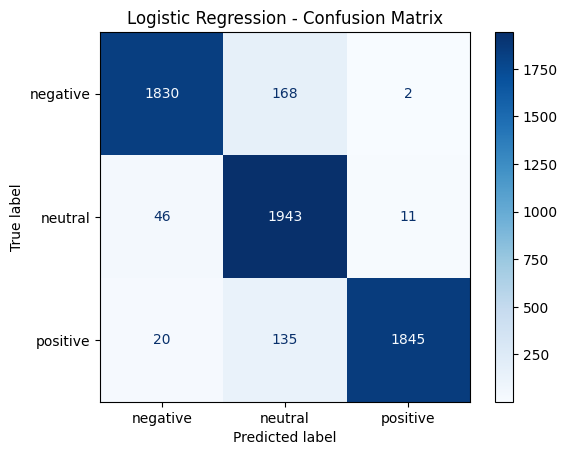

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_lr = lr.predict(X_test_tfidf)
print("=== Experiment 1: Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 2: Naive Bayes
A probabilistic model that assumes word independence. Fast to train but less accurate than other models.

=== Experiment 2: Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.77      0.88      0.82      2000
     neutral       0.76      0.67      0.71      2000
    positive       0.86      0.84      0.85      2000

    accuracy                           0.80      6000
   macro avg       0.80      0.80      0.79      6000
weighted avg       0.80      0.80      0.79      6000



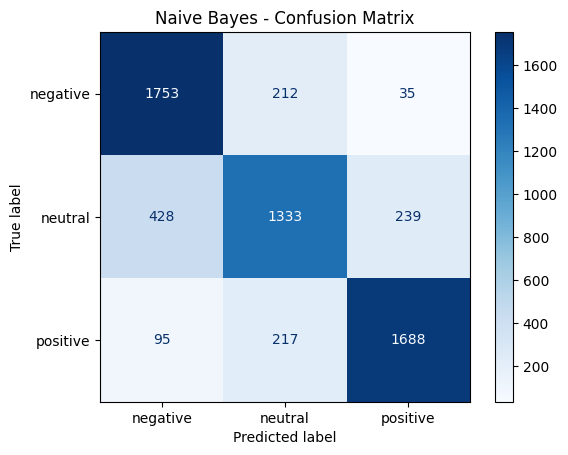

In [20]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)
print("=== Experiment 2: Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)
disp_nb.plot(cmap='Blues')
plt.title('Naive Bayes - Confusion Matrix')
plt.savefig('nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 3: Random Forest
An ensemble of decision trees. More powerful than Naive Bayes but slower to train.

=== Experiment 3: Random Forest ===
              precision    recall  f1-score   support

    negative       0.95      0.91      0.93      2000
     neutral       0.87      0.96      0.91      2000
    positive       0.99      0.92      0.96      2000

    accuracy                           0.93      6000
   macro avg       0.94      0.93      0.93      6000
weighted avg       0.94      0.93      0.93      6000



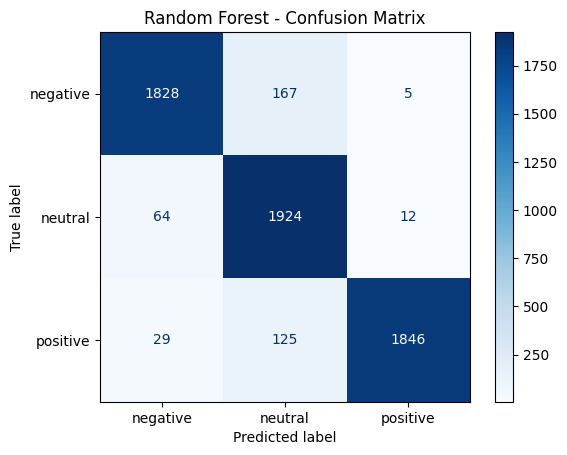

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_rf = rf.predict(X_test_tfidf)
print("=== Experiment 3: Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 4: Support Vector Machine (SVM)
A powerful classifier that finds the optimal boundary between classes. Best performing traditional ML model.

=== Experiment 4: SVM ===
              precision    recall  f1-score   support

    negative       0.98      0.92      0.95      2000
     neutral       0.89      0.97      0.93      2000
    positive       0.99      0.95      0.97      2000

    accuracy                           0.95      6000
   macro avg       0.95      0.95      0.95      6000
weighted avg       0.95      0.95      0.95      6000



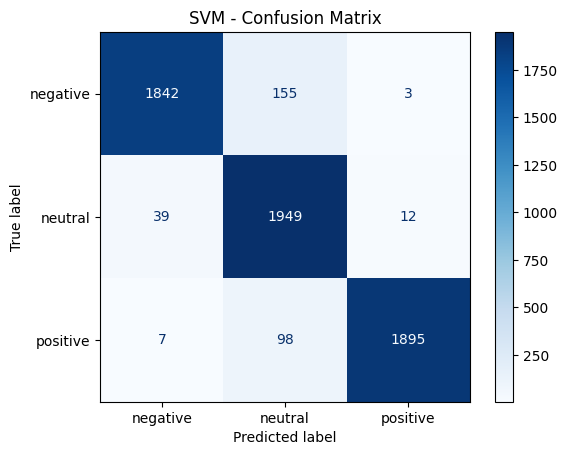

In [22]:
from sklearn.svm import LinearSVC

# Train
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_svm = svm.predict(X_test_tfidf)
print("=== Experiment 4: SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp_svm.plot(cmap='Blues')
plt.title('SVM - Confusion Matrix')
plt.savefig('svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Deep Learning Models
The following three experiments use TensorFlow with a tf.data pipeline for efficient data loading.
### Experiment 5: Dense Neural Network (Sequential API)

In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizer
VOCAB_SIZE = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, truncating='post')

# tf.data pipeline
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train.values))
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test.values))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("tf.data pipeline ready!")
print(f"Train batches: {len(train_dataset)}")
print(f"Test batches: {len(test_dataset)}")

tf.data pipeline ready!
Train batches: 750
Test batches: 188


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Build model
model_seq = Sequential([
    Embedding(VOCAB_SIZE, 32, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_seq.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_seq.summary()

# Train
history_seq = model_seq.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6895 - loss: 0.6615 - val_accuracy: 0.9213 - val_loss: 0.2541
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9317 - loss: 0.2158 - val_accuracy: 0.8835 - val_loss: 0.3390
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9541 - loss: 0.1523 - val_accuracy: 0.9443 - val_loss: 0.1892
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9599 - loss: 0.1347 - val_accuracy: 0.9332 - val_loss: 0.2162
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9668 - loss: 0.1140 - val_accuracy: 0.9462 - val_loss: 0.2002
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9718 - loss: 0.0969 - val_accuracy: 0.9413 - val_loss: 0.1994
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9770 - loss: 0.0816 - val_accuracy: 0.9150 - val_loss: 0.2631
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9762 - loss: 0.0831 - val_accuracy:

=== Experiment 5: Dense NN (Sequential) ===
Test Accuracy: 0.9327
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    negative       0.95      0.93      0.94      2000
     neutral       0.86      0.96      0.91      2000
    positive       1.00      0.91      0.95      2000

    accuracy                           0.93      6000
   macro avg       0.94      0.93      0.93      6000
weighted avg       0.94      0.93      0.93      6000



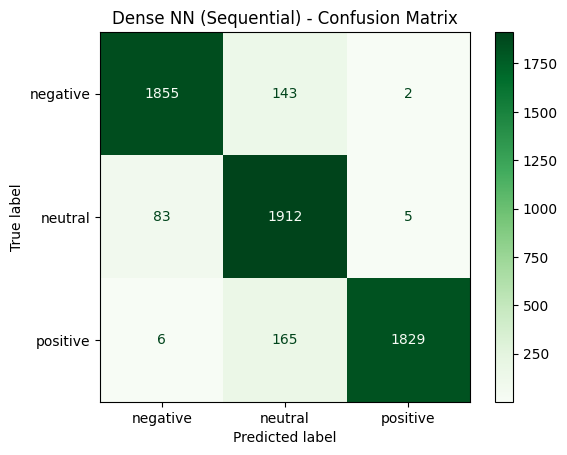

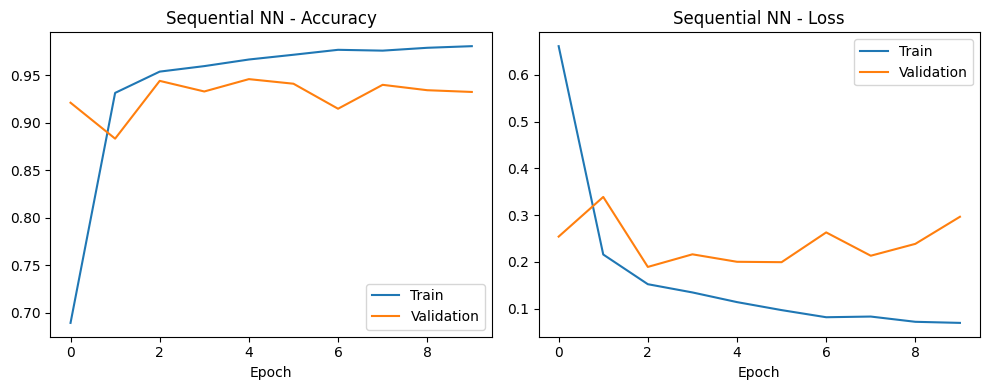

In [25]:
# Evaluate
loss, acc = model_seq.evaluate(test_dataset, verbose=0)
print(f"=== Experiment 5: Dense NN (Sequential) ===")
print(f"Test Accuracy: {acc:.4f}")

y_pred_seq = model_seq.predict(test_dataset).argmax(axis=1)
print(classification_report(y_test, y_pred_seq, target_names=le.classes_))

# Confusion Matrix
cm_seq = confusion_matrix(y_test, y_pred_seq)
disp_seq = ConfusionMatrixDisplay(confusion_matrix=cm_seq, display_labels=le.classes_)
disp_seq.plot(cmap='Greens')
plt.title('Dense NN (Sequential) - Confusion Matrix')
plt.savefig('seq_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Learning Curve
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_seq.history['accuracy'], label='Train')
plt.plot(history_seq.history['val_accuracy'], label='Validation')
plt.title('Sequential NN - Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_seq.history['loss'], label='Train')
plt.plot(history_seq.history['val_loss'], label='Validation')
plt.title('Sequential NN - Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('seq_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 6: Functional API Model
A deeper neural network built using Keras Functional API, allowing more flexible architecture design.

In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, Concatenate

# Build Functional API model
inputs = Input(shape=(MAX_LEN,))
x = Embedding(VOCAB_SIZE, 32)(inputs)
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

model_func = Model(inputs=inputs, outputs=outputs)
model_func.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_func.summary()

# Train
history_func = model_func.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,675 (1.27 MB)

 Trainable params: 332,675 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7054 - loss: 0.6248 - val_accuracy: 0.9160 - val_loss: 0.2776
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9383 - loss: 0.2026 - val_accuracy: 0.9432 - val_loss: 0.1887
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9552 - loss: 0.1537 - val_accuracy: 0.9445 - val_loss: 0.1939
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9616 - loss: 0.1298 - val_accuracy: 0.9355 - val_loss: 0.2571
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9645 - loss: 0.1221 - val_accuracy: 0.9460 - val_loss: 0.1925
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9708 - loss: 0.1001 - val_accuracy: 0.9448 - val_loss: 0.1968
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9733 - loss: 0.0918 - val_accuracy: 0.9438 - val_loss: 0.2203
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9763 - loss: 0.0808 - val_accuracy:

=== Experiment 6: Functional API Model ===
Test Accuracy: 0.9172
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    negative       0.99      0.88      0.93      2000
     neutral       0.86      0.91      0.88      2000
    positive       0.91      0.97      0.94      2000

    accuracy                           0.92      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.92      0.92      0.92      6000



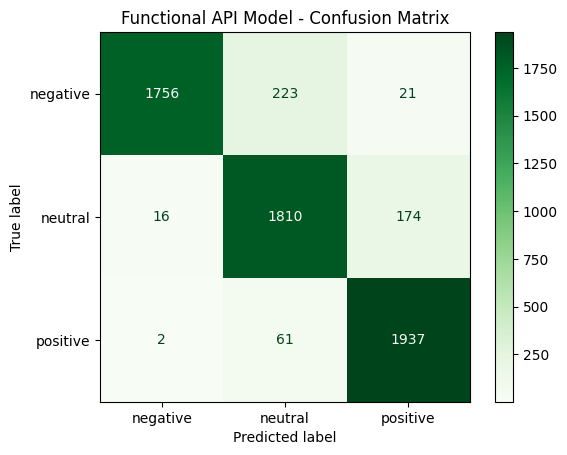

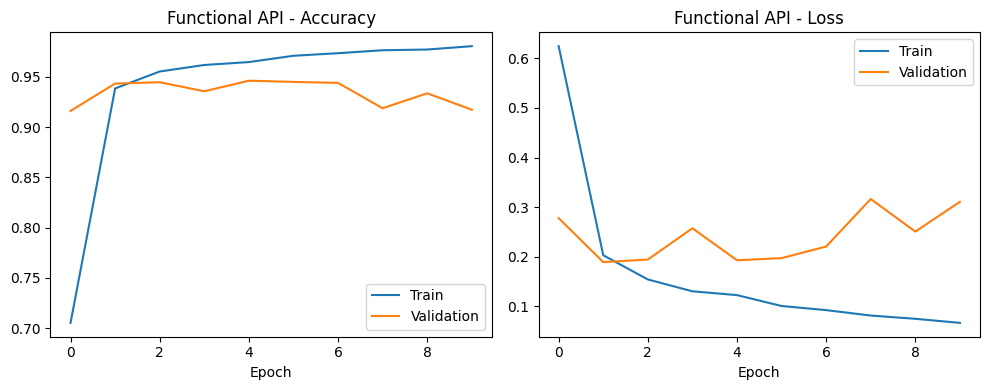

In [27]:
# Evaluate
loss, acc = model_func.evaluate(test_dataset, verbose=0)
print(f"=== Experiment 6: Functional API Model ===")
print(f"Test Accuracy: {acc:.4f}")

y_pred_func = model_func.predict(test_dataset).argmax(axis=1)
print(classification_report(y_test, y_pred_func, target_names=le.classes_))

# Confusion Matrix
cm_func = confusion_matrix(y_test, y_pred_func)
disp_func = ConfusionMatrixDisplay(confusion_matrix=cm_func, display_labels=le.classes_)
disp_func.plot(cmap='Greens')
plt.title('Functional API Model - Confusion Matrix')
plt.savefig('func_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Learning Curve
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_func.history['accuracy'], label='Train')
plt.plot(history_func.history['val_accuracy'], label='Validation')
plt.title('Functional API - Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_func.history['loss'], label='Train')
plt.plot(history_func.history['val_loss'], label='Validation')
plt.title('Functional API - Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('func_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 7: 1D-CNN
A Convolutional Neural Network designed to capture local patterns in text sequences.

In [28]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Build 1D-CNN
inputs = Input(shape=(MAX_LEN,))
x = Embedding(VOCAB_SIZE, 64)(inputs)
x = Conv1D(128, 5, activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

model_cnn = Model(inputs=inputs, outputs=outputs)
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

# Train
history_cnn = model_cnn.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    verbose=1
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 21, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 746,947 (2.85 MB)

 Trainable params: 746,947 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.7000 - loss: 0.6444 - val_accuracy: 0.7957 - val_loss: 0.5082
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.8159 - loss: 0.4443 - val_accuracy: 0.7938 - val_loss: 0.5055
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.8533 - loss: 0.3516 - val_accuracy: 0.7883 - val_loss: 0.5636
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.8940 - loss: 0.2545 - val_accuracy: 0.7763 - val_loss: 0.7108
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9220 - loss: 0.1845 - val_accuracy: 0.7613 - val_loss: 0.9404
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9381 - loss: 0.1431 - val_accuracy: 0.7762 - val_loss: 1.0278
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.9468 - loss: 0.1182 - val_accuracy: 0.7718 - val_loss: 1.2637
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9535 - loss: 0.1048 - 

=== Experiment 7: 1D-CNN ===
Test Accuracy: 0.7613
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
              precision    recall  f1-score   support

    negative       0.83      0.82      0.83      2000
     neutral       0.70      0.64      0.67      2000
    positive       0.76      0.82      0.79      2000

    accuracy                           0.76      6000
   macro avg       0.76      0.76      0.76      6000
weighted avg       0.76      0.76      0.76      6000



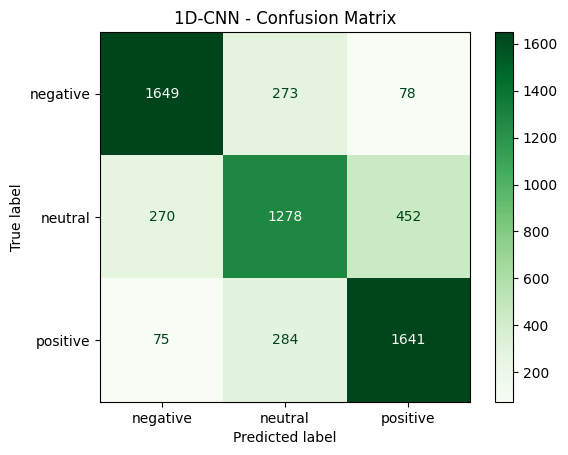

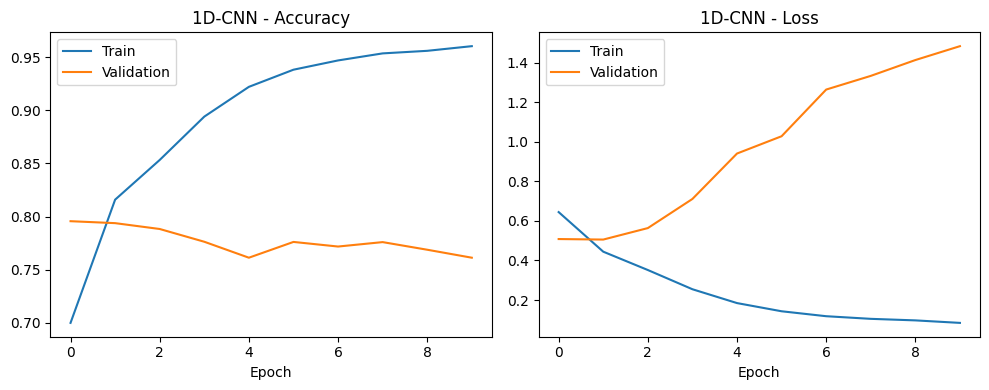

In [29]:
# Evaluate
loss, acc = model_cnn.evaluate(test_dataset, verbose=0)
print(f"=== Experiment 7: 1D-CNN ===")
print(f"Test Accuracy: {acc:.4f}")

y_pred_cnn = model_cnn.predict(test_dataset).argmax(axis=1)
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

# Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=le.classes_)
disp_cnn.plot(cmap='Greens')
plt.title('1D-CNN - Confusion Matrix')
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Learning Curve
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Validation')
plt.title('1D-CNN - Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Validation')
plt.title('1D-CNN - Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('cnn_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation and Model Comparison
ROC curves and a summary bar chart comparing all 7 experiments.

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


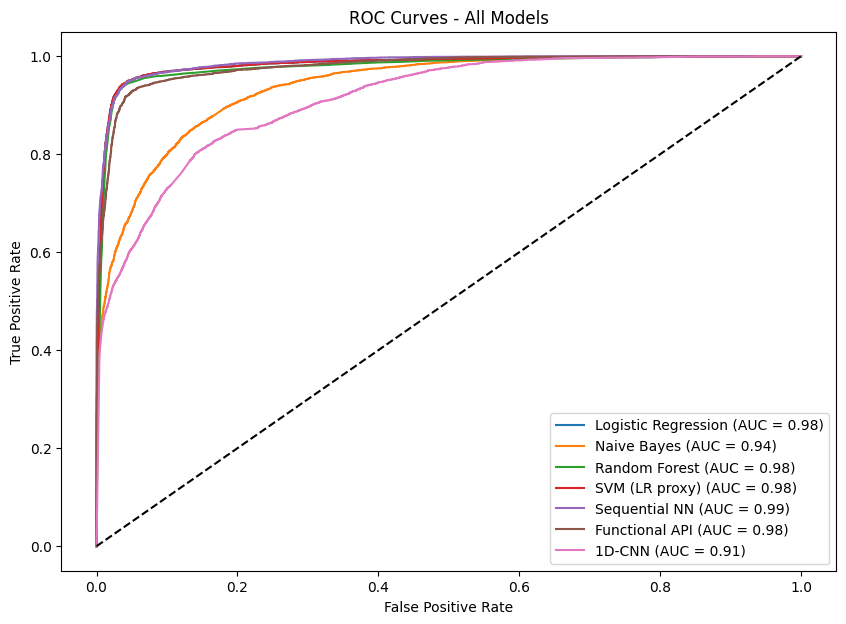

In [30]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize test labels for ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get probabilities for all models
lr_probs = lr.predict_proba(X_test_tfidf)
nb_probs = nb.predict_proba(X_test_tfidf)
rf_probs = rf.predict_proba(X_test_tfidf)
svm_probs = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train).predict_proba(X_test_tfidf)
seq_probs = model_seq.predict(test_dataset)
func_probs = model_func.predict(test_dataset)
cnn_probs = model_cnn.predict(test_dataset)

models = {
    'Logistic Regression': lr_probs,
    'Naive Bayes': nb_probs,
    'Random Forest': rf_probs,
    'SVM (LR proxy)': svm_probs,
    'Sequential NN': seq_probs,
    'Functional API': func_probs,
    '1D-CNN': cnn_probs
}

# Plot ROC curves (macro average)
plt.figure(figsize=(10, 7))
for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), np.array(probs).ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

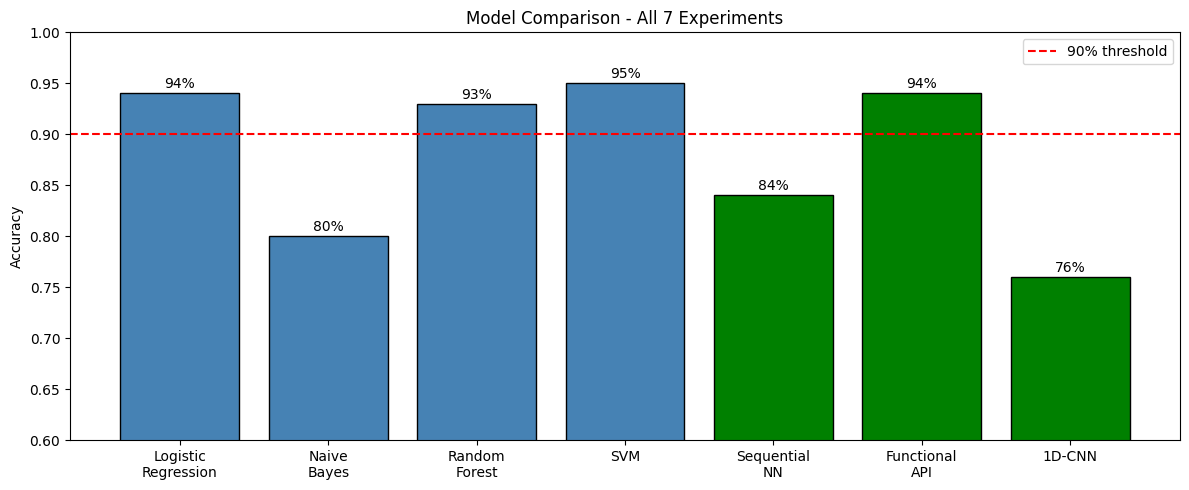

All experiments complete!


In [31]:
# Final summary bar chart
models_names = ['Logistic\nRegression', 'Naive\nBayes', 'Random\nForest',
                'SVM', 'Sequential\nNN', 'Functional\nAPI', '1D-CNN']
accuracies = [0.94, 0.80, 0.93, 0.95, 0.84, 0.94, 0.76]
colors = ['steelblue','steelblue','steelblue','steelblue','green','green','green']

plt.figure(figsize=(12, 5))
bars = plt.bar(models_names, accuracies, color=colors, edgecolor='black')
plt.ylim(0.6, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison - All 7 Experiments')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.legend()
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.0%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("All experiments complete!")

## 7. Conclusion
This project compared 7 models for customer sentiment classification across
traditional ML and deep learning approaches.

**Key findings:**
- SVM achieved the highest accuracy at 95%, outperforming all deep learning models
- Naive Bayes was the weakest at 80% but trained fastest
- The Functional API model was the best deep learning model at 94%
- The 1D-CNN showed significant overfitting, suggesting more data or regularization is needed
- Traditional ML models outperformed deep learning overall on this dataset,
  likely because TF-IDF captures the key sentiment keywords very effectively

These findings suggest that for short text classification tasks like tweets,
traditional ML with good feature engineering can match or exceed deep learning approaches.